# 01 — Hardware Specifications & γ Derivation

Survey published T₁ and t_gate values for the four target platforms, then derive the amplitude-damping parameter γ per platform.

**Convention:** `t_gate` is the representative single-layer gate time (typically a 1-qubit gate or the characteristic native gate) as reported per platform. See `data/hardware_specs/hardware_specs.csv` for citations.

**γ formula:**
$$\gamma = 1 - e^{-t_{\mathrm{gate}} / T_1}$$
where both $t_{\mathrm{gate}}$ and $T_1$ are expressed in the same units (ns).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## 1. Load Hardware Specifications

In [2]:
csv_path = os.path.join("..", "data", "hardware_specs", "hardware_specs.csv")
df = pd.read_csv(csv_path)
df

,platform,T1_us,t_gate_ns,source
0,IBM Quantum (Eagle),100,50,"Kim et al., Nature 618 500-505 (2023). https:/..."
1,Google Quantum AI (Sycamore),15,12,"Arute et al., Nature 574 505-510 (2019). https..."
2,Intel Tunnel Falls (spin),1000,1000,"Zwerver et al., Nature Electronics 5 184-190 (..."
3,IonQ Aria (trapped ion),10000000,135000,IonQ Aria system specifications (2023). https:...


## 2. Compute Derived Quantities

In [3]:
# Convert T1 from µs to ns for consistent units
df["T1_ns"] = df["T1_us"] * 1_000

# T1/t_gate ratio (dimensionless)
df["T1_t_gate_ratio"] = df["T1_ns"] / df["t_gate_ns"]

# Amplitude damping parameter: gamma = 1 - exp(-t_gate / T1)
df["gamma"] = 1 - np.exp(-df["t_gate_ns"] / df["T1_ns"])

display_cols = ["platform", "T1_us", "t_gate_ns", "T1_t_gate_ratio", "gamma"]

styled = df[display_cols].copy()
styled["T1_us"] = styled["T1_us"].apply(lambda x: f"{x:,.0f}")
styled["t_gate_ns"] = styled["t_gate_ns"].apply(lambda x: f"{x:,.0f}")
styled["T1_t_gate_ratio"] = styled["T1_t_gate_ratio"].apply(lambda x: f"{x:,.0f}")
styled["gamma"] = styled["gamma"].apply(lambda x: f"{x:.6f}")
styled.columns = ["Platform", "T₁ (µs)", "t_gate (ns)", "T₁/t_gate", "γ"]
styled

,Platform,T₁ (µs),t_gate (ns),T₁/t_gate,γ
0,IBM Quantum (Eagle),100,50,"2,000",0.000500
1,Google Quantum AI (Sycamore),15,12,"1,250",0.000800
2,Intel Tunnel Falls (spin),"1,000","1,000","1,000",0.001000
3,IonQ Aria (trapped ion),"10,000,000","135,000","74,074",0.000013


## 3. Sanity Checks

In [4]:
assert (df["gamma"] > 0).all(), "γ must be positive for all platforms"
assert (df["gamma"] < 1).all(), "γ must be less than 1 for all platforms"
assert (df["T1_t_gate_ratio"] > 1).all(), "T1/t_gate must exceed 1 (gate must be shorter than T1)"

print("All sanity checks passed.")
print()
print("γ interpretation — fraction of |1⟩ population lost per gate layer:")
for _, row in df.iterrows():
    print(f"  {row['platform']:<35}  γ = {row['gamma']:.2e}  ({row['gamma']*100:.4f}% decay/layer)")

All sanity checks passed.

γ interpretation — fraction of |1⟩ population lost per gate layer:
  IBM Quantum (Eagle)                  γ = 5.00e-04  (0.0500% decay/layer)
  Google Quantum AI (Sycamore)         γ = 8.00e-04  (0.0800% decay/layer)
  Intel Tunnel Falls (spin)            γ = 1.00e-03  (0.1000% decay/layer)
  IonQ Aria (trapped ion)              γ = 1.35e-05  (0.0013% decay/layer)


## 4. Bar Chart — γ per Platform

Saved: ../results/figures/gamma_per_platform.png


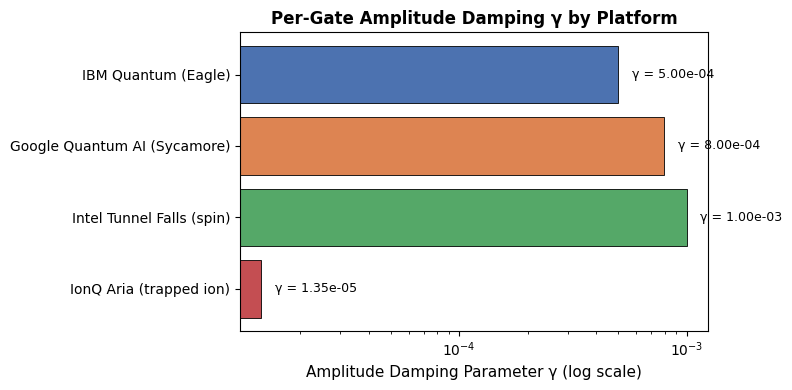

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = ax.barh(
    df["platform"],
    df["gamma"],
    color=colors,
    edgecolor="black",
    linewidth=0.6,
)

ax.set_xscale("log")
ax.set_xlabel("Amplitude Damping Parameter γ (log scale)", fontsize=11)
ax.set_title("Per-Gate Amplitude Damping γ by Platform", fontsize=12, fontweight="bold")
ax.invert_yaxis()  # highest γ (worst) at top

# Annotate bars with exact γ values
for bar, (_, row) in zip(bars, df.iterrows()):
    ax.text(
        bar.get_width() * 1.15,
        bar.get_y() + bar.get_height() / 2,
        f"γ = {row['gamma']:.2e}",
        va="center",
        fontsize=9,
    )

ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()

out_path = os.path.join("..", "results", "figures", "gamma_per_platform.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 5. Summary

The table below will be the canonical parameter source used by all subsequent notebooks.

| Platform | T₁ (µs) | t_gate (ns) | T₁/t_gate | γ |
|---|---|---|---|---|
| IBM Quantum (Eagle) | 100 | 50 | 2,000 | ~5×10⁻⁴ |
| Google Quantum AI (Sycamore) | 15 | 12 | 1,250 | ~8×10⁻⁴ |
| Intel Tunnel Falls (spin) | 1,000 | 1,000 | 1,000 | ~1×10⁻³ |
| IonQ Aria (trapped ion) | 10,000,000 | 135,000 | 74,074 | ~1.35×10⁻⁵ |

**Key takeaway:** IonQ Aria's γ is ~70× smaller than IBM's, primarily due to its extreme T₁. Intel's T₁/t_gate ratio is the lowest among the four platforms, making it the most noise-sensitive per gate despite its long absolute T₁.